Experiment 2: Implementing Feedforward Neural Networks (FNN)
This experiment allows students to implement and train a feedforward neural
network (FNN) for a classification task using backpropagation.

Test Accuracy: 1.0


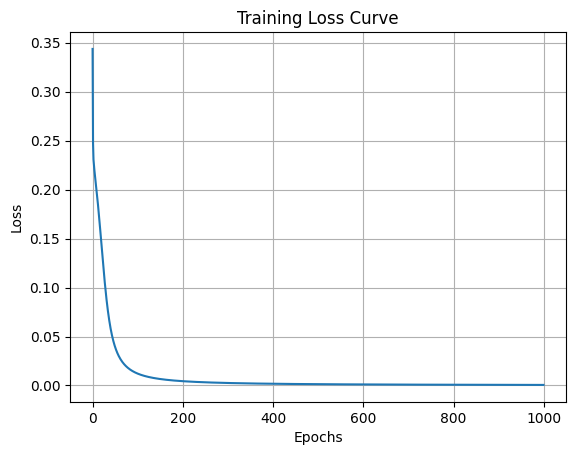

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# -------------------------------
# Step 1: Generate Dataset
# -------------------------------
np.random.seed(42)

# Class 0
class0 = np.random.randn(50, 2) + [2, 2]

# Class 1
class1 = np.random.randn(50, 2) + [6, 6]

X = np.vstack((class0, class1))
y = np.array([[0]]*50 + [[1]]*50)

# Normalize
X = X / np.max(X)

# -------------------------------
# Step 2: Train-Test Split
# -------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -------------------------------
# Step 3: Initialize Parameters
# -------------------------------
np.random.seed(0)

W1 = np.random.randn(2, 5)
b1 = np.zeros((1, 5))

W2 = np.random.randn(5, 1)
b2 = np.zeros((1, 1))

lr = 0.1
epochs = 1000

# -------------------------------
# Activation Functions
# -------------------------------
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def sigmoid_derivative(a):
    return a * (1 - a)

# -------------------------------
# Training
# -------------------------------
losses = []

for epoch in range(epochs):

    # Forward
    Z1 = np.dot(X_train, W1) + b1
    A1 = sigmoid(Z1)

    Z2 = np.dot(A1, W2) + b2
    A2 = sigmoid(Z2)

    # Loss
    loss = np.mean((y_train - A2) ** 2)
    losses.append(loss)

    # Backprop
    dA2 = (A2 - y_train)
    dZ2 = dA2 * sigmoid_derivative(A2)

    dW2 = np.dot(A1.T, dZ2)
    db2 = np.sum(dZ2, axis=0, keepdims=True)

    dA1 = np.dot(dZ2, W2.T)
    dZ1 = dA1 * sigmoid_derivative(A1)

    dW1 = np.dot(X_train.T, dZ1)
    db1 = np.sum(dZ1, axis=0, keepdims=True)

    # Update
    W1 -= lr * dW1
    b1 -= lr * db1
    W2 -= lr * dW2
    b2 -= lr * db2

# -------------------------------
# Testing
# -------------------------------
Z1_test = np.dot(X_test, W1) + b1
A1_test = sigmoid(Z1_test)

Z2_test = np.dot(A1_test, W2) + b2
A2_test = sigmoid(Z2_test)

predictions = (A2_test > 0.5).astype(int)
accuracy = np.mean(predictions == y_test)

print("Test Accuracy:", accuracy)

# -------------------------------
# Plot Loss Curve
# -------------------------------
plt.plot(losses)
plt.title("Training Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.grid()
plt.show()

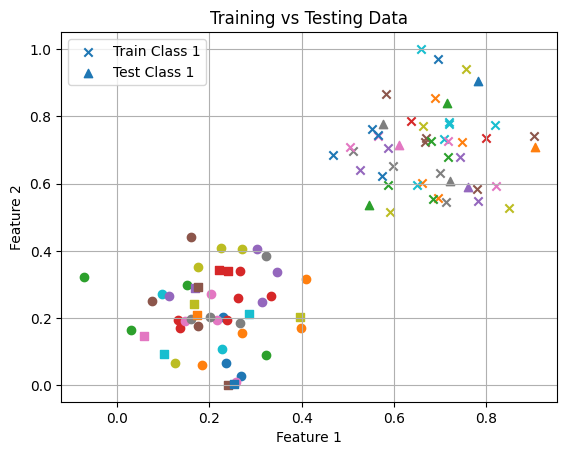

In [ ]:
# -------------------------------
# Visualize Train vs Test Data
# -------------------------------
plt.figure()

# Training data
for i in range(len(X_train)):
    if y_train[i] == 0:
        plt.scatter(X_train[i][0], X_train[i][1], marker='o', label='Train Class 0' if i == 0 else "")
    else:
        plt.scatter(X_train[i][0], X_train[i][1], marker='x', label='Train Class 1' if i == 0 else "")

# Testing data
for i in range(len(X_test)):
    if y_test[i] == 0:
        plt.scatter(X_test[i][0], X_test[i][1], marker='s', label='Test Class 0' if i == 0 else "")
    else:
        plt.scatter(X_test[i][0], X_test[i][1], marker='^', label='Test Class 1' if i == 0 else "")

plt.title("Training vs Testing Data")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid()

plt.show()

In [ ]:
# Training accuracy
train_pred = (A2 > 0.5).astype(int)
train_acc = np.mean(train_pred == y_train)

print("Train Accuracy:", train_acc)
print("Test Accuracy:", accuracy)

Train Accuracy: 1.0
Test Accuracy: 1.0
